# Merge MSOA and optimise on all groups

In [1]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

## Load data

Patient demographics by MSOA:

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [4]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [5]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [6]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [7]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [8]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [9]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [10]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [11]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [12]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

Pick out just the values for the left edges of the bins:

In [13]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [14]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [15]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [16]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


## Group LSOAs

In [17]:
def make_groups(df_here, n_groups=5):
    """Randomly assign groups."""
    # Setup:
    groups = np.zeros(len(df_here), dtype=int)
    inds_available = np.arange(len(df_here))
    
    # n_groups = 104  # 271  # 104
    group_sizes = int(len(df_here)/n_groups)
    n_larger_groups = len(df_here) - ((n_groups) * group_sizes)
    # group_extra = len(df_here) - ((n_groups - 1) * group_sizes)
    print(len(df_here), group_sizes, n_larger_groups)

    # Assign groups:
    for g in range(n_groups):
        # If this is one of the last groups in the list,
        # make it slightly bigger so that no MSOA are without a group.
        group_size = group_sizes if g <= (n_groups - n_larger_groups) else (group_sizes + 1)
        # Pick out which MSOA will go in this group:
        inds = np.random.choice(inds_available, size=group_size, replace=False)
        groups[inds] = g
        inds_available = list(set(inds_available) - set(inds))
    # Include results in starting dataframe:
    df_here = df_here.with_columns(pl.Series('group', groups))
    return df_here

In [18]:
def glob_msoa(df_here):
    dfs_to_glob = []
    
    cols_to_keep = ['admissions', 'All persons', 'age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']
    
    for g in sorted(df_here['group'].unique().to_numpy()):
        df_sum = df_here.filter(df_here['group'] == g).sum()
        # Only keep some columns:
        df_sum = df_sum[cols_to_keep]
        dfs_to_glob.append(df_sum)
    
    df_group_sums = pl.concat(dfs_to_glob)
    # Add label for group names:
    df_group_sums = df_group_sums.with_columns(pl.Series('group_label', np.arange(len(df_group_sums))))
    return df_group_sums

In [19]:
dict_group_sums = {}

np.random.seed(42)

for qmin in np.arange(0.0, 1.0, 0.2):
    df_here = df_stats.filter(np.round(df_stats['depriv_quantile_min'], 1) == round(qmin, 1))
    # Aim for this many MSOA per group:
    group_sizes = 10
    n_groups = int(len(df_here) / group_sizes)
    df_here = make_groups(df_here, n_groups)
    # Gather data for these groups:
    df_group_sums = glob_msoa(df_here)
    print(df_here['admissions'].sum(), df_group_sums['admissions'].sum())
    # Store results:
    dict_group_sums[qmin] = df_group_sums

1359 10 9
16420.333333359995 16420.333333359995
1358 10 8
16204.000000007994 16204.000000007998
1357 10 7
16441.999999973 16441.999999973006
1358 10 8
16418.999999996002 16418.999999996005
1358 10 8
15472.666666653999 15472.666666653999


In [20]:
for qmin, df in dict_group_sums.items():
    print(qmin)
    display(df)

0.0


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
149.333333,86970,69175.3244,4063.6504,3840.3202,2671.205,3741.4093,0
157.666667,82766,67284.8688,3329.6813,3183.5808,2130.7739,3228.3981,1
88.0,71847,59069.8507,2369.282,2034.1582,1428.2,1898.0714,2
112.0,88450,69498.5516,2652.9703,2465.7103,1661.7745,2376.6827,3
104.666667,86940,71571.9989,2986.5653,2737.6533,1862.3288,2517.8599,4
…,…,…,…,…,…,…,…
123.666667,92662,73218.0101,3590.5663,3147.8077,2465.6076,3412.4501,130
131.0,86068,69981.4038,3462.0075,3042.4465,2042.6908,2786.2987,131
111.0,97519,77674.2599,2968.9101,2654.895,1869.5163,2782.1295,132


0.2


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
157.666667,87453,67215.1001,4205.4287,4280.637,3288.0965,5041.093,0
109.333333,79835,62447.5766,3275.1742,2995.3813,2187.6822,3087.4879,1
130.333333,91837,71970.5362,3546.7941,3501.196,2490.3022,3298.9105,2
142.0,88852,69783.8799,4012.8993,3934.8563,2976.3901,3685.2261,3
112.666667,79300,62405.7589,3948.1208,4243.6119,2890.9421,4059.5397,4
…,…,…,…,…,…,…,…
128.0,95450,73091.7913,3682.8387,3624.2591,2661.2392,3705.0637,130
120.0,104098,83374.9005,3665.1816,3301.0716,2311.4204,3315.0288,131
120.0,91086,72198.8786,3932.1271,3660.2592,2563.2965,3498.1262,132


0.4


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
117.0,80262,61306.2087,4562.4501,4909.3382,3520.7613,4507.4985,0
142.0,82898,62017.0005,4638.1729,4847.4982,3705.3503,4754.5761,1
127.666667,73301,55444.5253,4321.9294,4318.209,3148.2979,4485.2338,2
91.0,88803,71256.7042,2852.3061,2713.6898,1886.1913,2800.5829,3
142.333333,94102,69872.4889,5142.1015,5391.901,3737.1361,5274.2849,4
…,…,…,…,…,…,…,…
154.666667,99889,74955.1868,4792.9826,4777.9647,3334.1042,4606.9261,130
152.333333,90478,68627.8829,4687.0596,4773.4691,3331.1124,5183.6051,131
140.666667,92642,68732.8633,5261.2109,5497.3827,3975.2703,5752.0423,132


0.6000000000000001


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
139.666667,97372,72965.1898,4983.0538,5183.0283,3630.9945,5152.4752,0
114.666667,76873,55822.6481,4242.5438,4094.892,3106.0219,4411.0171,1
148.333333,82676,60945.7428,4602.3364,5067.5743,3859.9853,5338.4529,2
131.333333,91135,71884.1544,4276.5878,4387.9599,3265.7133,4498.7284,3
114.0,86052,63425.1474,4561.0467,4742.6012,3236.0695,4226.4249,4
…,…,…,…,…,…,…,…
137.0,89451,65513.4032,5355.9001,5570.8119,4060.2217,6633.7576,130
141.333333,78144,58256.7093,4955.0128,4972.1262,3473.4202,5150.5549,131
134.333333,82285,60642.5279,4865.4928,5400.6311,3957.6093,5433.8975,132


0.8


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
136.333333,86209,65523.9051,4154.6193,4628.1563,3472.2064,5681.7912,0
117.333333,81711,60569.7824,4009.9721,4238.1264,3081.488,4123.5411,1
105.0,75067,54222.4045,3898.7016,4446.4486,3227.3309,5035.4479,2
118.666667,88553,66342.3289,4557.5216,4476.6825,3231.3032,4308.4053,3
125.333333,73180,53250.9729,4119.1788,4714.3998,3414.3977,5096.7537,4
…,…,…,…,…,…,…,…
123.0,92734,68459.4218,5028.4387,5593.4549,3884.5948,4962.6149,130
116.666667,85896,64965.6509,4164.5417,4399.7435,3223.9478,4542.9636,131
121.333333,88598,68014.876,4417.7959,4906.1881,3547.8314,4973.5513,132


In [21]:
qmin_list = list(dict_group_sums.keys())

## Function for optimising

In [454]:
def main_opt(coeffs, args):
    all_calculated_admissions = []
    all_observed_admissions = sum([list(a) for a in args[1]], [])

    coeffs = np.round(coeffs, 7)
    
    coeffs_grid = np.array(coeffs).reshape(5, 5)
    for i, q in enumerate(qmin_list):
        coeffs_q = coeffs_grid[i, :]
        x_lists = args[0][i]
        admissions = args[1][i]
        
        calculated_admissions = predict_admissions(x_lists, np.array(coeffs_q))

        all_calculated_admissions += list(calculated_admissions)

    # Calculate measure of difference from the observed admissions:
    # print(
    #     np.array(all_calculated_admissions),
    #     np.array(all_observed_admissions)
    # )
    # diff = find_mean_abs_diff(
    diff = find_square_residuals(
        np.array(all_calculated_admissions),
        np.array(all_observed_admissions)
    )
    diff_before = diff
    n_penalty = 0
    use_penalty = True
    if use_penalty:
        # Check coefficient conditions. If any aren't met, add a penalty
        # to the main difference measure.
        n_decrease = 0.0
        for i, q in enumerate(qmin_list):
            # Pick out coeffs for this depriv quantile:
            coeffs_q = coeffs_grid[i, :]
            # Do all coeffs increase with age band?
            n_decrease += sum(np.sign(np.diff(coeffs_q)) < 0)

        n_increase = 0.0
        for i, a in enumerate(age_numbers):
            # Pick out coeffs for this age band:
            coeffs_q = coeffs_grid[:, i]
            # Do all coeffs decrease with depriv quantile?
            n_increase += sum(np.sign(np.diff(coeffs_q)) > 0)

        # Add penalty:
        n_penalty = n_increase + n_decrease
        if n_penalty > 0.0:
            diff += (n_penalty * abs(diff) * 0.2)
    # print(diff_before, n_penalty, diff)
    # print(coeffs_grid)
    # # print(n_decrease, n_increase, diff)
    # print('\n' * 3)
    return diff

In [23]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [24]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (yhat - y)**2.0
    # Sum of differences:
    sum_sqres = np.sqrt(sqres.sum())
    return sum_sqres

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [25]:
def find_mean_abs_diff(yhat, y):
    # Difference from actual:
    absres = np.abs((yhat - y))
    # Mean of differences:
    mean_absres = absres.mean()
    return mean_absres

To check accuracy, the following function calculates R-squared:

In [26]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

## Optimise:

Set up options for how much the SSNAP coefficients can be scaled by:

In [72]:
scale_options = np.round(np.arange(0.6, 1.41, 0.2), 1)

scale_options

array([0.6, 0.8, 1. , 1.2, 1.4])

In [73]:
from itertools import product

In [74]:
import numpy as np

In [75]:
scale_option_combos = np.array([s for s in product(scale_options, repeat=5)])

# Only keep combos where scales decrease/stay same with depriv quantile
# (i.e. scale is larger when deprivation higher):
mask = (np.diff(scale_option_combos, axis=1) <= 0.0).all(axis=1)

scale_option_combos = scale_option_combos[mask]

In [76]:
len(scale_option_combos)

126

In [77]:
scale_option_combos[:5]

array([[0.6, 0.6, 0.6, 0.6, 0.6],
       [0.8, 0.6, 0.6, 0.6, 0.6],
       [0.8, 0.8, 0.6, 0.6, 0.6],
       [0.8, 0.8, 0.8, 0.6, 0.6],
       [0.8, 0.8, 0.8, 0.8, 0.6]])

In [78]:
scale_option_combos[-5:]

array([[1.4, 1.4, 1.4, 1.4, 0.6],
       [1.4, 1.4, 1.4, 1.4, 0.8],
       [1.4, 1.4, 1.4, 1.4, 1. ],
       [1.4, 1.4, 1.4, 1.4, 1.2],
       [1.4, 1.4, 1.4, 1.4, 1.4]])

Set up SSNAP coefficients:

In [79]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

In [80]:
# from previous notebook
coeffs_ssnap = [0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

Set up all combos of starting coefficients:

In [81]:
# Store start combos of coeffs in here:
coeffs_init_start = {}

for s, scale_options_here in enumerate(scale_option_combos):
    coeffs_init = list(np.round(np.concatenate([np.array(coeffs_ssnap) * s for s in scale_options_here]), 8))
    coeffs_init_start[s] = coeffs_init

# coeffs_init_grid = np.array(coeffs_init).reshape(5, 5)
# # To get all coeffs for one age band:        coeffs_init_grid[:, 0]
# # To get all coeffs for one depriv quantile: coeffs_init_grid[0, :]

In [82]:
df_coeffs_init = pl.concat([pl.DataFrame([c], schema=coeff_names) for c in coeffs_init_start.values()]).cast(float)

df_coeffs_init = df_coeffs_init.with_columns(pl.Series('coeff_combo', coeffs_init_start.keys()).cast(int))
# Move this column to start:
df_coeffs_init = df_coeffs_init.drop('coeff_combo').insert_column(0, df_coeffs_init.get_column('coeff_combo'))


In [83]:
df_coeffs_init

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348
1,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348
2,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348
3,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348
4,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0002448,0.0015864,0.002241,0.003603,0.0069348
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
121,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0002448,0.0015864,0.002241,0.003603,0.0069348
122,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0003264,0.0021152,0.002988,0.004804,0.0092464
123,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.000408,0.002644,0.003735,0.006005,0.011558


In [84]:
df_coeffs_init.write_csv(os.path.join('outputs', 'multi_optimise_coeffs_init.csv'))

In [85]:
for coeff_combo in list(coeffs_init_start.keys())[:3]:
    print(coeff_combo, coeffs_init_start[coeff_combo])

0 [0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348]
1 [0.0003264, 0.0021152, 0.002988, 0.004804, 0.0092464, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348]
2 [0.0003264, 0.0021152, 0.002988, 0.004804, 0.0092464, 0.0003264, 0.0021152, 0.002988, 0.004804, 0.0092464, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348, 0.0002448, 0.0015864, 0.002241, 0.003603, 0.0069348]


In [86]:
coeffs_init_start_test = {}

for coeff_combo in list(coeffs_init_start.keys())[40:43]:
    coeffs_init_start_test[coeff_combo] = coeffs_init_start[coeff_combo]

## Run grid

In [87]:
dict_coeffs = {}
dict_opt_results = {}
# Store these opt results keys:
opt_results_keys = ['message', 'success', 'status', 'nit', 'nfev']

i = 1
for coeff_combo, coeffs_init in coeffs_init_start.items():
    print(f'{i:5d} out of {len(coeffs_init_start)}', end='\r')
    i += 1
    bounds_here = [(0.0, 1.0)] * len(coeffs_init)  # force results to lie between 0 and 1
    
    all_x_lists = []
    all_admissions = []
    for qmin, df_group_sums in dict_group_sums.items():
        # MSOA data in the same order as those coefficients:
        x_lists = [df_group_sums[a] for a in age_numbers]
        admissions = df_group_sums['admissions'].to_numpy()
        all_x_lists.append(x_lists)
        all_admissions.append(admissions)
    
    # Run the optimiser:
    opt_results = minimize(
        main_opt,
        x0=coeffs_init,
        args=[all_x_lists, all_admissions],
        bounds=bounds_here,
        method='Nelder-Mead',
        # method='SLSQP',
        options=dict(maxiter=10000),
    )
    # Pick out the resulting health coefficients:
    coeffs = np.round(opt_results['x'], 7)

    # Calculate R^2 here:

    # Log whether this combo optimised successfully:
    dict_opt_results[coeff_combo] = pl.DataFrame(np.array([[f'{coeff_combo}'] + [opt_results[k] for k in opt_results_keys]]), schema=['coeff_combo'] + opt_results_keys)
    # pl.Series(f'{coeff_combo}', [opt_results[k] for k in opt_results_keys], strict=False).to_frame()
    # Store coeffs:
    dict_coeffs[coeff_combo] = pl.DataFrame(np.array([[f'{coeff_combo}'] + list(coeffs)]), schema=['coeff_combo'] + coeff_names)
    # pl.Series(f'{coeff_combo}', coeffs).to_frame()

Gather results into dataFrames:

In [88]:
df_opt_results = pl.concat(dict_opt_results.values())

df_opt_results = df_opt_results.with_columns(pl.Series('coeff_combo', df_opt_results['coeff_combo'].cast(int)))

In [89]:
df_opt_results

coeff_combo,message,success,status,nit,nfev
i64,str,str,str,str,str
0,"""Optimization terminated succes…","""True""","""0""","""54""","""491"""
1,"""Optimization terminated succes…","""True""","""0""","""808""","""1452"""
2,"""Optimization terminated succes…","""True""","""0""","""85""","""546"""
3,"""Optimization terminated succes…","""True""","""0""","""83""","""497"""
4,"""Optimization terminated succes…","""True""","""0""","""76""","""509"""
…,…,…,…,…,…
121,"""Optimization terminated succes…","""True""","""0""","""45""","""471"""
122,"""Optimization terminated succes…","""True""","""0""","""41""","""463"""
123,"""Optimization terminated succes…","""True""","""0""","""81""","""515"""


In [90]:
df_coeffs = pl.concat(dict_coeffs.values()).cast(float)

df_coeffs = df_coeffs.with_columns(pl.Series('coeff_combo', df_coeffs['coeff_combo'].cast(int)))

In [91]:
df_coeffs

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0002448,0.0015864,0.002241,0.003603,0.0071082,0.0002448,0.0015864,0.002241,0.003603,0.0070222,0.0002448,0.0015864,0.002241,0.003603,0.0070046,0.0002448,0.0015864,0.002241,0.003603,0.0069511,0.0002448,0.0015864,0.002241,0.003603,0.0069348
1,0.0003266,0.0021156,0.0029827,0.004813,0.009219,0.0002451,0.0015886,0.002245,0.0036141,0.0071193,0.0002451,0.0015862,0.0022412,0.003605,0.0070394,0.0002448,0.0015859,0.002241,0.0036024,0.0070394,0.0002444,0.0015858,0.0022365,0.0036013,0.0069613
2,0.0003265,0.0021152,0.0029882,0.004804,0.0092465,0.0003264,0.0021152,0.002988,0.004804,0.0092465,0.0002448,0.0015864,0.002241,0.003603,0.0071421,0.0002448,0.0015864,0.002241,0.003603,0.007073,0.0002448,0.0015864,0.002241,0.003603,0.0069349
3,0.0003265,0.0021156,0.0029886,0.004805,0.0092484,0.0003265,0.0021149,0.0029878,0.0048044,0.0092484,0.0003265,0.0021148,0.0029877,0.0048008,0.0092484,0.0002449,0.0015867,0.0022415,0.0036038,0.0072722,0.0002449,0.0015861,0.0022409,0.0036007,0.0069364
4,0.0003265,0.0021152,0.002988,0.004804,0.0095969,0.0003264,0.0021152,0.002988,0.004804,0.0092465,0.0003264,0.0021152,0.002988,0.004804,0.0092465,0.0003264,0.0021152,0.002988,0.004804,0.0092465,0.0002448,0.0015864,0.002241,0.003603,0.0070175
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
121,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0145631,0.0002463,0.0015959,0.0022544,0.0036246,0.0069764
122,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0145631,0.0003284,0.0021279,0.0030059,0.0048328,0.0093019
123,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0145631,0.0004104,0.0026599,0.0037574,0.006041,0.0116273


In [92]:
df_coeffs_init

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348
1,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348
2,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348
3,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0002448,0.0015864,0.002241,0.003603,0.0069348,0.0002448,0.0015864,0.002241,0.003603,0.0069348
4,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0003264,0.0021152,0.002988,0.004804,0.0092464,0.0002448,0.0015864,0.002241,0.003603,0.0069348
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
121,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0002448,0.0015864,0.002241,0.003603,0.0069348
122,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0003264,0.0021152,0.002988,0.004804,0.0092464
123,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.0005712,0.0037016,0.005229,0.008407,0.0161812,0.000408,0.002644,0.003735,0.006005,0.011558


Check result:

In [93]:
qmin_list = np.round(qmin_list, 1)

In [293]:
list_r2_dicts = []

for coeff_combo in df_coeffs['coeff_combo']:
    dict_r2 = {}
    mask = df_coeffs['coeff_combo'] == coeff_combo
    row_coeffs = df_coeffs.filter(mask)

    df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))
    
    for q in qmin_list:
        qstr = str(round(q, 1)).replace('.', '')
        df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)
        
        for a in age_numbers:
            df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (row_coeffs[f'{a}_q{qstr}'].to_numpy()[0] * df_here[a])))

        # R2 for just this q:
        r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
        dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)
        
        mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])

        # df_admissions_here = df_admissions_here.with_columns(
        #    pl.when(mask)
        #      .then(df_here['admissions_predicted'])
        #      .otherwise(pl.col('admissions_predicted'))
        #      .name.keep()
        # )
        df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
        
    cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))
    
    # Calculate R2:
    r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
    dict_r2['r2_all'] = np.round(r2, 5)
    # Calculate residuals:
    res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
    dict_r2['res'] = np.round(res, 3)
            

    list_r2_dicts.append(pl.DataFrame([[coeff_combo] + list(dict_r2.values())], schema=['coeff_combo'] + list(dict_r2.keys())))

In [294]:
# Convert results to dataframe:
df_r2 = pl.concat(list_r2_dicts, how='vertical')

In [295]:
df_r2

coeff_combo,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
i64,f64,f64,f64,f64,f64,f64,f64
0,-1.96769,-1.08925,-0.56076,-0.46175,-0.15083,-0.81531,501.784
1,-0.80493,-1.06458,-0.5524,-0.44198,-0.14743,-0.59532,470.398
2,-0.8011,-0.09088,-0.53225,-0.43424,-0.1508,-0.3932,439.591
3,-0.80056,-0.09042,0.29923,-0.38951,-0.15066,-0.19862,407.739
4,-0.74613,-0.09088,0.29919,0.4006,-0.13381,-0.0269,377.403
…,…,…,…,…,…,…,…
121,0.44716,0.16988,-0.36378,-0.66869,-0.13182,-0.12277,394.627
122,0.44716,0.16988,-0.36378,-0.66869,0.5494,0.00784,370.964
123,0.44716,0.16988,-0.36378,-0.66869,0.48844,-0.00384,373.143


In [296]:
df_r2.sort('res')

coeff_combo,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
i64,f64,f64,f64,f64,f64,f64,f64
79,0.49571,0.58209,0.63653,0.60773,0.62211,0.59308,237.572
44,0.49644,0.58237,0.63579,0.60858,0.61934,0.59274,237.671
77,0.4976,0.58128,0.6401,0.60904,0.60729,0.59147,238.041
99,0.48626,0.57555,0.63342,0.60536,0.61366,0.58728,239.26
42,0.4964,0.57873,0.6373,0.59279,0.60484,0.58639,239.519
…,…,…,…,…,…,…,…
2,-0.8011,-0.09088,-0.53225,-0.43424,-0.1508,-0.3932,439.591
125,0.44716,0.16988,-0.36378,-1.12097,-1.27912,-0.43366,445.928
6,0.01005,-1.07093,-0.55278,-0.4507,-0.1508,-0.45292,448.914


Merge R2 results into main optimisation results:

In [298]:
df_opt_results = df_opt_results.join(df_r2, on='coeff_combo', how='left')

In [299]:
df_opt_results

coeff_combo,message,success,status,nit,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64
0,"""Optimization terminated succes…","""True""","""0""","""54""","""491""",-1.96769,-1.08925,-0.56076,-0.46175,-0.15083,-0.81531,501.784
1,"""Optimization terminated succes…","""True""","""0""","""808""","""1452""",-0.80493,-1.06458,-0.5524,-0.44198,-0.14743,-0.59532,470.398
2,"""Optimization terminated succes…","""True""","""0""","""85""","""546""",-0.8011,-0.09088,-0.53225,-0.43424,-0.1508,-0.3932,439.591
3,"""Optimization terminated succes…","""True""","""0""","""83""","""497""",-0.80056,-0.09042,0.29923,-0.38951,-0.15066,-0.19862,407.739
4,"""Optimization terminated succes…","""True""","""0""","""76""","""509""",-0.74613,-0.09088,0.29919,0.4006,-0.13381,-0.0269,377.403
…,…,…,…,…,…,…,…,…,…,…,…,…
121,"""Optimization terminated succes…","""True""","""0""","""45""","""471""",0.44716,0.16988,-0.36378,-0.66869,-0.13182,-0.12277,394.627
122,"""Optimization terminated succes…","""True""","""0""","""41""","""463""",0.44716,0.16988,-0.36378,-0.66869,0.5494,0.00784,370.964
123,"""Optimization terminated succes…","""True""","""0""","""81""","""515""",0.44716,0.16988,-0.36378,-0.66869,0.48844,-0.00384,373.143


In [300]:
df_results = df_opt_results.join(df_coeffs, on='coeff_combo', how='left')

In [301]:
df_results

coeff_combo,message,success,status,nit,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""Optimization terminated succes…","""True""","""0""","""54""","""491""",-1.96769,-1.08925,-0.56076,-0.46175,-0.15083,-0.81531,501.784,0.0002448,0.0015864,0.002241,0.003603,0.0071082,0.0002448,0.0015864,0.002241,0.003603,0.0070222,0.0002448,0.0015864,0.002241,0.003603,0.0070046,0.0002448,0.0015864,0.002241,0.003603,0.0069511,0.0002448,0.0015864,0.002241,0.003603,0.0069348
1,"""Optimization terminated succes…","""True""","""0""","""808""","""1452""",-0.80493,-1.06458,-0.5524,-0.44198,-0.14743,-0.59532,470.398,0.0003266,0.0021156,0.0029827,0.004813,0.009219,0.0002451,0.0015886,0.002245,0.0036141,0.0071193,0.0002451,0.0015862,0.0022412,0.003605,0.0070394,0.0002448,0.0015859,0.002241,0.0036024,0.0070394,0.0002444,0.0015858,0.0022365,0.0036013,0.0069613
2,"""Optimization terminated succes…","""True""","""0""","""85""","""546""",-0.8011,-0.09088,-0.53225,-0.43424,-0.1508,-0.3932,439.591,0.0003265,0.0021152,0.0029882,0.004804,0.0092465,0.0003264,0.0021152,0.002988,0.004804,0.0092465,0.0002448,0.0015864,0.002241,0.003603,0.0071421,0.0002448,0.0015864,0.002241,0.003603,0.007073,0.0002448,0.0015864,0.002241,0.003603,0.0069349
3,"""Optimization terminated succes…","""True""","""0""","""83""","""497""",-0.80056,-0.09042,0.29923,-0.38951,-0.15066,-0.19862,407.739,0.0003265,0.0021156,0.0029886,0.004805,0.0092484,0.0003265,0.0021149,0.0029878,0.0048044,0.0092484,0.0003265,0.0021148,0.0029877,0.0048008,0.0092484,0.0002449,0.0015867,0.0022415,0.0036038,0.0072722,0.0002449,0.0015861,0.0022409,0.0036007,0.0069364
4,"""Optimization terminated succes…","""True""","""0""","""76""","""509""",-0.74613,-0.09088,0.29919,0.4006,-0.13381,-0.0269,377.403,0.0003265,0.0021152,0.002988,0.004804,0.0095969,0.0003264,0.0021152,0.002988,0.004804,0.0092465,0.0003264,0.0021152,0.002988,0.004804,0.0092465,0.0003264,0.0021152,0.002988,0.004804,0.0092465,0.0002448,0.0015864,0.002241,0.003603,0.0070175
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
121,"""Optimization terminated succes…","""True""","""0""","""45""","""471""",0.44716,0.16988,-0.36378,-0.66869,-0.13182,-0.12277,394.627,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0145631,0.0002463,0.0015959,0.0022544,0.0036246,0.0069764
122,"""Optimization terminated succes…","""True""","""0""","""41""","""463""",0.44716,0.16988,-0.36378,-0.66869,0.5494,0.00784,370.964,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0145631,0.0003284,0.0021279,0.0030059,0.0048328,0.0093019
123,"""Optimization terminated succes…","""True""","""0""","""81""","""515""",0.44716,0.16988,-0.36378,-0.66869,0.48844,-0.00384,373.143,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0162783,0.0005746,0.0037238,0.0052604,0.0084574,0.0145631,0.0004104,0.0026599,0.0037574,0.006041,0.0116273


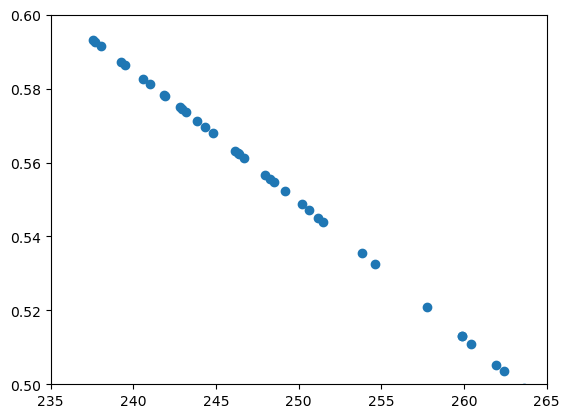

In [308]:
fig, ax  = plt.subplots()

ax.scatter(df_results['res'], df_results['r2_all'])
ax.set_ylim(0.5, 0.6)
ax.set_xlim(235, 265)
plt.show()

In [302]:
df_results.write_csv(os.path.join('outputs', 'multi_optimise_coeffs_results.csv'))

In [102]:
print(stop, here, please)

NameError: name 'stop' is not defined

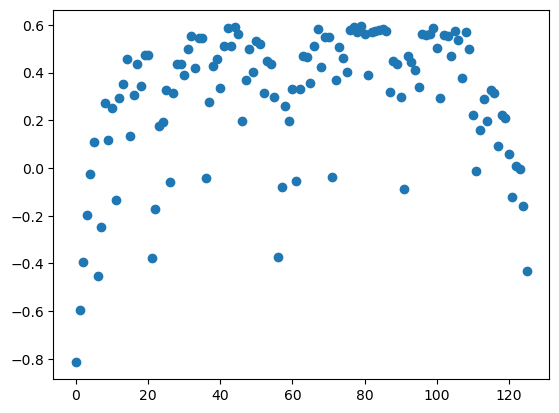

In [103]:
fig, ax = plt.subplots()

ax.scatter(df_results['coeff_combo'], df_results['r2_all'])

plt.show()

In [229]:
df_top_results = df_results.filter(df_results['r2_all'] >= 0.5).sort('r2_all', descending=True)

df_top_results

coeff_combo,message,success,status,nit,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
79,"""Optimization terminated succes…","""True""","""0""","""2215""","""3086""",0.49571,0.58209,0.63653,0.60773,0.62211,0.59308,0.0005888,0.0035083,0.0043078,0.0070402,0.0152672,0.0005071,0.0031985,0.0042896,0.0067051,0.0124262,0.0004138,0.002827,0.0038346,0.0061564,0.0117222,0.0003422,0.0026926,0.0034715,0.0056789,0.0116553,0.0002854,0.0021336,0.0034132,0.0045961,0.0116538
44,"""Optimization terminated succes…","""True""","""0""","""1664""","""2328""",0.49644,0.58237,0.63579,0.60858,0.61934,0.59274,0.0006168,0.002976,0.0047067,0.0071269,0.0146852,0.0004914,0.0029553,0.0043007,0.0061705,0.013335,0.0004089,0.0026432,0.004223,0.00617,0.0115396,0.0004086,0.0025675,0.0030072,0.0054003,0.0115182,0.0003465,0.0023196,0.002547,0.0049842,0.0113126
77,"""Optimization terminated succes…","""True""","""0""","""1346""","""2024""",0.4976,0.58128,0.6401,0.60904,0.60729,0.59147,0.0006372,0.0034211,0.0055175,0.0059382,0.0137354,0.0004635,0.0034202,0.0040709,0.0059352,0.0137304,0.000429,0.0023319,0.0033669,0.0056021,0.0129531,0.0003928,0.002331,0.0032291,0.0056001,0.0116387,0.0003926,0.0022035,0.0031517,0.0050362,0.009879
99,"""Optimization terminated succes…","""True""","""0""","""1439""","""2247""",0.48626,0.57555,0.63342,0.60536,0.61366,0.58728,0.0006129,0.003738,0.0052696,0.0111402,0.0115632,0.0004694,0.0036266,0.0051717,0.0076988,0.0115622,0.0004007,0.0027475,0.0037344,0.0060398,0.0115615,0.0003847,0.002626,0.003679,0.0059538,0.0106793,0.0003479,0.0016523,0.0035694,0.0047215,0.0106792
42,"""Optimization terminated succes…","""True""","""0""","""1550""","""2436""",0.4964,0.57873,0.6373,0.59279,0.60484,0.58639,0.0006207,0.0042957,0.0042962,0.0076384,0.0131354,0.0004526,0.003096,0.0040448,0.0076374,0.0131283,0.0003575,0.0021616,0.0037753,0.0055982,0.0130373,0.000351,0.0021032,0.0036545,0.005241,0.0110389,0.0003204,0.0019769,0.0027841,0.0045385,0.0110373
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
41,"""Optimization terminated succes…","""True""","""0""","""1824""","""2682""",0.45731,0.58149,0.61535,0.53792,0.33959,0.51315,0.0004935,0.0032848,0.004042,0.0084371,0.0142423,0.0004935,0.0030869,0.0036382,0.0064637,0.0139556,0.0003364,0.0028762,0.0031223,0.0064471,0.0116521,0.0003337,0.0020056,0.002085,0.005029,0.0116507,0.0003332,0.0014799,0.0020814,0.0023864,0.009973
43,"""Optimization terminated succes…","""True""","""0""","""1332""","""2068""",0.3915,0.5798,0.63042,0.60776,0.31188,0.5131,0.0004719,0.0032231,0.004129,0.0073417,0.0135505,0.0004697,0.0027746,0.0041289,0.0073352,0.0134197,0.0004072,0.0027713,0.0041286,0.0064804,0.0122102,0.0003565,0.0025793,0.0033731,0.0059119,0.0116336,0.0001688,0.0021405,0.0024018,0.0024021,0.0107123
66,"""Optimization terminated succes…","""True""","""0""","""1358""","""2155""",0.48715,0.55849,0.61647,0.56588,0.29386,0.51098,0.0005011,0.0026181,0.0061789,0.006195,0.0162327,0.0004371,0.0023847,0.0039489,0.0061634,0.0133097,0.0003995,0.002257,0.0033433,0.0055992,0.0117817,0.0003982,0.002257,0.0033381,0.00494,0.010151,0.0003729,0.0017132,0.0017134,0.0023618,0.0093625


In [230]:
positions = np.vstack([np.arange(5)]*5) + np.vstack([np.arange(-0.2, 0.3, 0.1)]*5).T

positions

array([[-0.2,  0.8,  1.8,  2.8,  3.8],
       [-0.1,  0.9,  1.9,  2.9,  3.9],
       [ 0. ,  1. ,  2. ,  3. ,  4. ],
       [ 0.1,  1.1,  2.1,  3.1,  4.1],
       [ 0.2,  1.2,  2.2,  3.2,  4.2]])

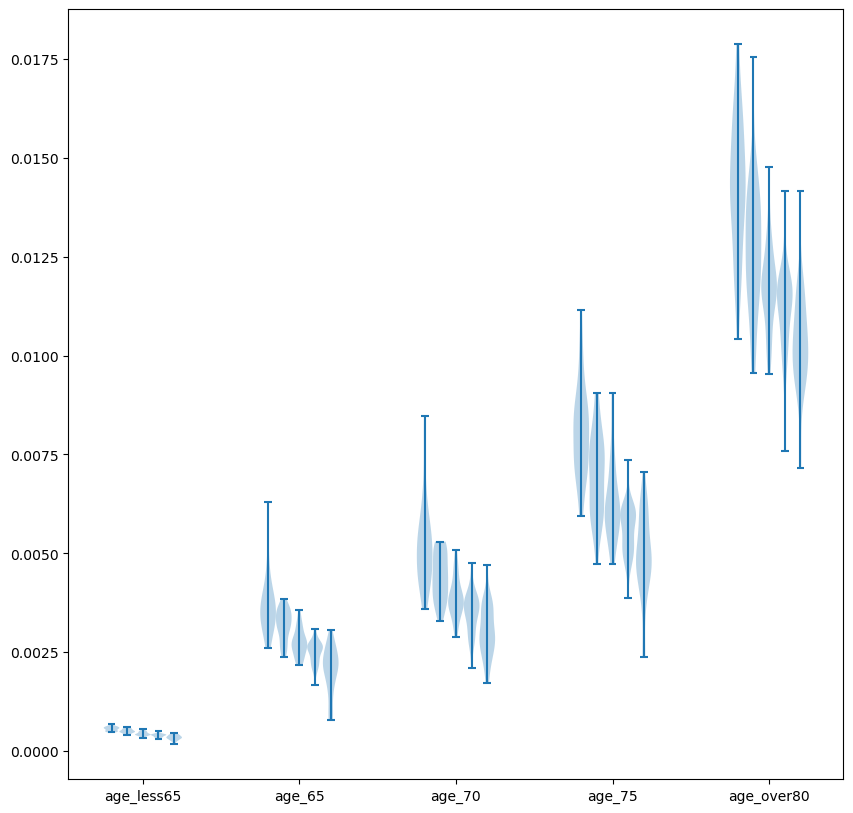

In [231]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.violinplot(df_top_results[coeff_names], positions=positions.flatten(), widths=0.1)

ax.set_xticks(np.arange(5))
ax.set_xticklabels(age_numbers)

plt.show()

In [232]:
df_top_results_mean = df_top_results[coeff_names].mean().to_numpy().reshape(5, 5)
df_top_results_std = df_top_results[coeff_names].std().to_numpy().reshape(5, 5)

In [233]:
np.round(df_top_results_mean + df_top_results_std, 5)

array([[0.00061, 0.00444, 0.00632, 0.00926, 0.01606],
       [0.00055, 0.00358, 0.00499, 0.00802, 0.01437],
       [0.00048, 0.00308, 0.00438, 0.00733, 0.01285],
       [0.00043, 0.00278, 0.00401, 0.00622, 0.01227],
       [0.0004 , 0.00262, 0.00368, 0.006  , 0.01159]])

In [234]:
np.round(df_top_results_mean, 5)

array([[0.00056, 0.00368, 0.00523, 0.00809, 0.01432],
       [0.0005 , 0.00318, 0.0044 , 0.00696, 0.01274],
       [0.00043, 0.00273, 0.00387, 0.00632, 0.01174],
       [0.00039, 0.00248, 0.00348, 0.00557, 0.01116],
       [0.00033, 0.00202, 0.00302, 0.0049 , 0.01033]])

In [235]:
np.round(df_top_results_mean - df_top_results_std, 5)

array([[0.0005 , 0.00292, 0.00414, 0.00692, 0.01257],
       [0.00044, 0.00279, 0.0038 , 0.00591, 0.01111],
       [0.00038, 0.00237, 0.00336, 0.00531, 0.01064],
       [0.00034, 0.00218, 0.00294, 0.00492, 0.01006],
       [0.00026, 0.00142, 0.00236, 0.00379, 0.00907]])

In [236]:
np.round(df_top_results_std, 5)

array([[6.00e-05, 7.60e-04, 1.09e-03, 1.17e-03, 1.75e-03],
       [5.00e-05, 4.00e-04, 5.90e-04, 1.06e-03, 1.63e-03],
       [5.00e-05, 3.50e-04, 5.10e-04, 1.01e-03, 1.11e-03],
       [4.00e-05, 3.00e-04, 5.30e-04, 6.50e-04, 1.10e-03],
       [7.00e-05, 6.00e-04, 6.60e-04, 1.11e-03, 1.26e-03]])

In [237]:
for best_combo_name in df_top_results['coeff_combo']:

    df_best = df_results.filter(df_results['coeff_combo'] == best_combo_name)
    
    df_best_coeffs = df_best[coeff_names]
    best_coeffs_grid = df_best_coeffs.to_numpy().reshape(5, 5)

    print(best_combo_name)
    display(np.round(best_coeffs_grid, 4))
    display(np.round(best_coeffs_grid / coeffs_ssnap, 2))
    print('\n'*3)

79


array([[0.0006, 0.0035, 0.0043, 0.007 , 0.0153],
       [0.0005, 0.0032, 0.0043, 0.0067, 0.0124],
       [0.0004, 0.0028, 0.0038, 0.0062, 0.0117],
       [0.0003, 0.0027, 0.0035, 0.0057, 0.0117],
       [0.0003, 0.0021, 0.0034, 0.0046, 0.0117]])

array([[1.44, 1.33, 1.15, 1.17, 1.32],
       [1.24, 1.21, 1.15, 1.12, 1.08],
       [1.01, 1.07, 1.03, 1.03, 1.01],
       [0.84, 1.02, 0.93, 0.95, 1.01],
       [0.7 , 0.81, 0.91, 0.77, 1.01]])





44


array([[0.0006, 0.003 , 0.0047, 0.0071, 0.0147],
       [0.0005, 0.003 , 0.0043, 0.0062, 0.0133],
       [0.0004, 0.0026, 0.0042, 0.0062, 0.0115],
       [0.0004, 0.0026, 0.003 , 0.0054, 0.0115],
       [0.0003, 0.0023, 0.0025, 0.005 , 0.0113]])

...

array([[0.0006, 0.0026, 0.0037, 0.0069, 0.0179],
       [0.0006, 0.0024, 0.0033, 0.0055, 0.0152],
       [0.0004, 0.0024, 0.0029, 0.0051, 0.0129],
       [0.0003, 0.002 , 0.0029, 0.005 , 0.0099],
       [0.0002, 0.0009, 0.0029, 0.005 , 0.0098]])

array([[1.47, 0.98, 0.99, 1.16, 1.55],
       [1.44, 0.92, 0.88, 0.92, 1.32],
       [0.87, 0.9 , 0.77, 0.84, 1.12],
       [0.82, 0.76, 0.77, 0.84, 0.86],
       [0.43, 0.36, 0.77, 0.84, 0.85]])





100


array([[0.0006, 0.0037, 0.0053, 0.0085, 0.0163],
       [0.0006, 0.0037, 0.0053, 0.0085, 0.0146],
       [0.0004, 0.0027, 0.0038, 0.006 , 0.0116],
       [0.0004, 0.0027, 0.0038, 0.006 , 0.0116],
       [0.0004, 0.0027, 0.0038, 0.006 , 0.0116]])

array([[1.41, 1.41, 1.41, 1.41, 1.41],
       [1.41, 1.41, 1.41, 1.41, 1.26],
       [1.01, 1.01, 1.01, 1.01, 1.01],
       [1.01, 1.01, 1.01, 1.01, 1.01],
       [1.01, 1.01, 1.01, 1.01, 1.01]])

## Set up inputs for simulated annealing

Round the results from before.

In [219]:
df_anneal_init = df_results.sort('r2_all', descending=True)

In [221]:
dict_round = {'age_less65': 4, 'age_65': 3, 'age_70': 3, 'age_75': 3, 'age_over80': 3}

for a in age_numbers:
    n = dict_round[a]
    for q in qmin_list:
        qstr = str(round(q, 1)).replace('.', '')
        col = f'{a}_q{qstr}'
        df_anneal_init = df_anneal_init.with_columns(pl.Series(col, np.round(df_anneal_init[col], n)))

Only keep results with decent r-squared:

In [223]:
df_anneal_init = df_anneal_init.filter(df_anneal_init['r2_all'] >= 0.5)

In [225]:
len(df_anneal_init)

35

In [224]:
df_anneal_init.unique(subset=coeff_names, keep='first', maintain_order=True)

coeff_combo,message,success,status,nit,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
79,"""Optimization terminated succes…","""True""","""0""","""2215""","""3086""",0.49571,0.58209,0.63653,0.60773,0.62211,0.59308,0.0006,0.004,0.004,0.007,0.015,0.0005,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0003,0.003,0.003,0.006,0.012,0.0003,0.002,0.003,0.005,0.012
44,"""Optimization terminated succes…","""True""","""0""","""1664""","""2328""",0.49644,0.58237,0.63579,0.60858,0.61934,0.59274,0.0006,0.003,0.005,0.007,0.015,0.0005,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.003,0.005,0.012,0.0003,0.002,0.003,0.005,0.011
77,"""Optimization terminated succes…","""True""","""0""","""1346""","""2024""",0.4976,0.58128,0.6401,0.60904,0.60729,0.59147,0.0006,0.003,0.006,0.006,0.014,0.0005,0.003,0.004,0.006,0.014,0.0004,0.002,0.003,0.006,0.013,0.0004,0.002,0.003,0.006,0.012,0.0004,0.002,0.003,0.005,0.01
99,"""Optimization terminated succes…","""True""","""0""","""1439""","""2247""",0.48626,0.57555,0.63342,0.60536,0.61366,0.58728,0.0006,0.004,0.005,0.011,0.012,0.0005,0.004,0.005,0.008,0.012,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.006,0.011,0.0003,0.002,0.004,0.005,0.011
42,"""Optimization terminated succes…","""True""","""0""","""1550""","""2436""",0.4964,0.57873,0.6373,0.59279,0.60484,0.58639,0.0006,0.004,0.004,0.008,0.013,0.0005,0.003,0.004,0.008,0.013,0.0004,0.002,0.004,0.006,0.013,0.0004,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.011
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
41,"""Optimization terminated succes…","""True""","""0""","""1824""","""2682""",0.45731,0.58149,0.61535,0.53792,0.33959,0.51315,0.0005,0.003,0.004,0.008,0.014,0.0005,0.003,0.004,0.006,0.014,0.0003,0.003,0.003,0.006,0.012,0.0003,0.002,0.002,0.005,0.012,0.0003,0.001,0.002,0.002,0.01
43,"""Optimization terminated succes…","""True""","""0""","""1332""","""2068""",0.3915,0.5798,0.63042,0.60776,0.31188,0.5131,0.0005,0.003,0.004,0.007,0.014,0.0005,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.003,0.006,0.012,0.0002,0.002,0.002,0.002,0.011
66,"""Optimization terminated succes…","""True""","""0""","""1358""","""2155""",0.48715,0.55849,0.61647,0.56588,0.29386,0.51098,0.0005,0.003,0.006,0.006,0.016,0.0004,0.002,0.004,0.006,0.013,0.0004,0.002,0.003,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0004,0.002,0.002,0.002,0.009


In [227]:
df_anneal_init[coeff_names].mean().to_numpy().reshape(5, 5)

array([[0.00056   , 0.00371429, 0.0052    , 0.00797143, 0.01431429],
       [0.0005    , 0.00317143, 0.00445714, 0.00697143, 0.01277143],
       [0.00042857, 0.00274286, 0.00397143, 0.00631429, 0.01188571],
       [0.00038571, 0.00257143, 0.00354286, 0.00554286, 0.01134286],
       [0.00032571, 0.00202857, 0.00308571, 0.00488571, 0.01031429]])

### Run annealing

In [246]:
from scipy.optimize import basinhopping

In [435]:
coeffs_anneal_init_start = {}

for coeff_combo in df_anneal_init['coeff_combo']:
    coeffs = df_anneal_init.filter(df_anneal_init['coeff_combo'] == coeff_combo)[coeff_names].to_numpy()
    coeffs_anneal_init_start[coeff_combo] = list(coeffs[0])

In [455]:
dict_anneal_coeffs = {}
dict_anneal_opt_results = {}
# Store these opt results keys:
opt_results_keys = ['success', 'nit', 'minimization_failures', 'nfev']

i = 1
for coeff_combo, coeffs_init in coeffs_anneal_init_start.items():
    print(f'{i:5d} out of {len(coeffs_anneal_init_start)}', end='\r')
    i += 1
    bounds_here = [(0.0, 1.0)] * len(coeffs_init)  # force results to lie between 0 and 1
    
    all_x_lists = []
    all_admissions = []
    for qmin, df_group_sums in dict_group_sums.items():
        # MSOA data in the same order as those coefficients:
        x_lists = [df_group_sums[a] for a in age_numbers]
        admissions = df_group_sums['admissions'].to_numpy()
        all_x_lists.append(x_lists)
        all_admissions.append(admissions)
    
    # Run the optimiser:
    opt_results = basinhopping(
        main_opt,
        x0=coeffs_init,
        T=30.0,  # experiment
        stepsize=5e-5,
        minimizer_kwargs = dict(
            args=[all_x_lists, all_admissions],
            # bounds=[(0.0, 1.0)] * len(age_coeffs),  # force results to lie between 0 and 1
            bounds=bounds_here,
            method='Nelder-Mead',
            options=dict(maxiter=10000),
            ),
    )
    # Pick out the resulting health coefficients:
    coeffs = np.round(opt_results['x'], 7)

    # Calculate R^2 here:

    # Log whether this combo optimised successfully:
    opt_results_to_save = [opt_results['message'][0]] + [opt_results[k] for k in opt_results_keys]
    dict_anneal_opt_results[coeff_combo] = pl.DataFrame(np.array([[f'{coeff_combo}'] + opt_results_to_save]), schema=['coeff_combo', 'message'] + opt_results_keys)
    # pl.Series(f'{coeff_combo}', [opt_results[k] for k in opt_results_keys], strict=False).to_frame()
    # Store coeffs:
    dict_anneal_coeffs[coeff_combo] = pl.DataFrame(np.array([[f'{coeff_combo}'] + list(coeffs)]), schema=['coeff_combo'] + coeff_names)
    # pl.Series(f'{coeff_combo}', coeffs).to_frame()

Gather results into dataFrames:

In [459]:
df_anneal_opt_results = pl.concat(dict_anneal_opt_results.values())

df_anneal_opt_results = df_anneal_opt_results.with_columns(pl.Series('coeff_combo', df_anneal_opt_results['coeff_combo'].cast(int)))

In [460]:
df_anneal_opt_results

coeff_combo,message,success,nit,minimization_failures,nfev
i64,str,str,str,str,str
79,"""requested number of basinhoppi…","""True""","""100""","""0""","""177041"""
44,"""requested number of basinhoppi…","""True""","""100""","""0""","""179357"""
77,"""requested number of basinhoppi…","""True""","""100""","""0""","""172091"""
99,"""requested number of basinhoppi…","""True""","""100""","""0""","""180651"""
42,"""requested number of basinhoppi…","""True""","""100""","""0""","""176698"""
…,…,…,…,…,…
41,"""requested number of basinhoppi…","""True""","""100""","""0""","""180086"""
43,"""requested number of basinhoppi…","""True""","""100""","""0""","""178981"""
66,"""requested number of basinhoppi…","""True""","""100""","""0""","""179292"""


In [461]:
df_anneal_coeffs = pl.concat(dict_anneal_coeffs.values()).cast(float)

df_anneal_coeffs = df_anneal_coeffs.with_columns(pl.Series('coeff_combo', df_anneal_coeffs['coeff_combo'].cast(int)))

In [462]:
df_anneal_coeffs

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
79,0.0005943,0.0030936,0.0066295,0.0068126,0.0134062,0.0005555,0.0025696,0.0029554,0.0068098,0.0134062,0.0004168,0.0024093,0.0029233,0.0055252,0.0134053,0.0003348,0.0023408,0.0028641,0.0045966,0.0133829,0.0002737,0.0023074,0.0026505,0.0033797,0.0131937
44,0.0005903,0.0031295,0.0061421,0.0062133,0.0143481,0.0005699,0.0025356,0.0026058,0.0058422,0.0141907,0.0004522,0.0021978,0.0024619,0.0046462,0.0141867,0.0003279,0.0021325,0.0023699,0.0045319,0.0141806,0.0002409,0.002094,0.0023451,0.0036751,0.0138665
77,0.0005927,0.0030561,0.0065211,0.0065365,0.0137685,0.000555,0.0025213,0.0031027,0.0061819,0.0137682,0.000445,0.0019151,0.0026733,0.0054802,0.0137679,0.000359,0.0018645,0.0023354,0.005173,0.0136209,0.000283,0.0018281,0.0023299,0.0043262,0.0131526
99,0.0005944,0.0036772,0.006583,0.0065978,0.0129104,0.0005515,0.0030502,0.0031747,0.0065789,0.0129098,0.0004348,0.0025558,0.0031743,0.0057414,0.0125977,0.0003499,0.0024574,0.0029342,0.0053551,0.0124652,0.0002256,0.0024574,0.0029336,0.0049205,0.0123456
42,0.0005737,0.0032831,0.0070498,0.0074233,0.0127927,0.0005462,0.0023667,0.003571,0.0073508,0.0127915,0.000429,0.0020305,0.0035135,0.0060709,0.0126241,0.0003377,0.0020292,0.0032674,0.0054652,0.0126232,0.0002126,0.0020291,0.0032674,0.0050893,0.0124073
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
41,0.0005761,0.0027823,0.0027983,0.009336,0.015163,0.0005761,0.0025037,0.0027241,0.0065828,0.0136776,0.0004119,0.0020861,0.0026438,0.0056697,0.0136776,0.0003469,0.0013611,0.0018397,0.0056298,0.0136759,0.0003454,0.0010571,0.0015931,0.0021976,0.0136754
43,0.0005772,0.0046689,0.0048811,0.0053062,0.0148371,0.00057,0.0024259,0.0024519,0.0053059,0.014837,0.0004538,0.0017551,0.0022758,0.004823,0.0146588,0.0003739,0.0017548,0.0022449,0.0037429,0.0146426,0.0002851,0.0017528,0.0022044,0.0029949,0.0142229
66,0.0005875,0.0027292,0.006551,0.0065611,0.0142201,0.0005548,0.0021085,0.0028054,0.0065598,0.0142197,0.000483,0.0005992,0.0026727,0.0058616,0.0142195,0.000438,0.0005199,0.0026357,0.0042753,0.0142178,0.0002533,0.0024806,0.0025241,0.0026271,0.0139321


Check result:

In [463]:
qmin_list = np.round(qmin_list, 1)

In [464]:
list_anneal_r2_dicts = []

for coeff_combo in df_anneal_coeffs['coeff_combo']:
    dict_r2 = {}
    mask = df_anneal_coeffs['coeff_combo'] == coeff_combo
    row_coeffs = df_anneal_coeffs.filter(mask)

    df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))
    
    for q in qmin_list:
        qstr = str(round(q, 1)).replace('.', '')
        df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)
        
        for a in age_numbers:
            df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (row_coeffs[f'{a}_q{qstr}'].to_numpy()[0] * df_here[a])))

        # R2 for just this q:
        r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
        dict_r2[f'q{qstr}'] = np.round(r2_q, 5)
        
        mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])

        # df_admissions_here = df_admissions_here.with_columns(
        #    pl.when(mask)
        #      .then(df_here['admissions_predicted'])
        #      .otherwise(pl.col('admissions_predicted'))
        #      .name.keep()
        # )
        df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
        
    cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))
    
    # Calculate R2:
    r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
            
    dict_r2['all'] = np.round(r2, 5)

    list_anneal_r2_dicts.append(pl.DataFrame([[coeff_combo] + list(dict_r2.values())], schema=['coeff_combo'] + [f'r2_{r}' for r in list(dict_r2.keys())]))

In [465]:
# Convert results to dataframe:
df_anneal_r2 = pl.concat(list_anneal_r2_dicts, how='vertical')

In [466]:
df_anneal_r2

coeff_combo,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all
i64,f64,f64,f64,f64,f64,f64
79,0.49557,0.5836,0.64152,0.61191,0.62633,0.59612
44,0.49622,0.58376,0.64227,0.61291,0.62742,0.59685
77,0.49586,0.58396,0.64202,0.61332,0.62628,0.59663
99,0.49587,0.58327,0.63926,0.61057,0.62415,0.59492
42,0.49365,0.58306,0.63954,0.61056,0.62392,0.59449
…,…,…,…,…,…,…
41,0.48824,0.58329,0.64151,0.60773,0.58936,0.58681
43,0.4972,0.58389,0.64315,0.61458,0.62782,0.59766
66,0.49542,0.58395,0.64187,0.61492,0.62763,0.5971


Merge R2 results into main optimisation results:

In [467]:
df_anneal_opt_results = df_anneal_opt_results.join(df_anneal_r2, on='coeff_combo', how='left')

In [468]:
df_anneal_opt_results

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64
79,"""requested number of basinhoppi…","""True""","""100""","""0""","""177041""",0.49557,0.5836,0.64152,0.61191,0.62633,0.59612
44,"""requested number of basinhoppi…","""True""","""100""","""0""","""179357""",0.49622,0.58376,0.64227,0.61291,0.62742,0.59685
77,"""requested number of basinhoppi…","""True""","""100""","""0""","""172091""",0.49586,0.58396,0.64202,0.61332,0.62628,0.59663
99,"""requested number of basinhoppi…","""True""","""100""","""0""","""180651""",0.49587,0.58327,0.63926,0.61057,0.62415,0.59492
42,"""requested number of basinhoppi…","""True""","""100""","""0""","""176698""",0.49365,0.58306,0.63954,0.61056,0.62392,0.59449
…,…,…,…,…,…,…,…,…,…,…,…
41,"""requested number of basinhoppi…","""True""","""100""","""0""","""180086""",0.48824,0.58329,0.64151,0.60773,0.58936,0.58681
43,"""requested number of basinhoppi…","""True""","""100""","""0""","""178981""",0.4972,0.58389,0.64315,0.61458,0.62782,0.59766
66,"""requested number of basinhoppi…","""True""","""100""","""0""","""179292""",0.49542,0.58395,0.64187,0.61492,0.62763,0.5971


In [469]:
df_anneal_results = df_anneal_opt_results.join(df_anneal_coeffs, on='coeff_combo', how='left')

In [470]:
df_anneal_results

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
79,"""requested number of basinhoppi…","""True""","""100""","""0""","""177041""",0.49557,0.5836,0.64152,0.61191,0.62633,0.59612,0.0005943,0.0030936,0.0066295,0.0068126,0.0134062,0.0005555,0.0025696,0.0029554,0.0068098,0.0134062,0.0004168,0.0024093,0.0029233,0.0055252,0.0134053,0.0003348,0.0023408,0.0028641,0.0045966,0.0133829,0.0002737,0.0023074,0.0026505,0.0033797,0.0131937
44,"""requested number of basinhoppi…","""True""","""100""","""0""","""179357""",0.49622,0.58376,0.64227,0.61291,0.62742,0.59685,0.0005903,0.0031295,0.0061421,0.0062133,0.0143481,0.0005699,0.0025356,0.0026058,0.0058422,0.0141907,0.0004522,0.0021978,0.0024619,0.0046462,0.0141867,0.0003279,0.0021325,0.0023699,0.0045319,0.0141806,0.0002409,0.002094,0.0023451,0.0036751,0.0138665
77,"""requested number of basinhoppi…","""True""","""100""","""0""","""172091""",0.49586,0.58396,0.64202,0.61332,0.62628,0.59663,0.0005927,0.0030561,0.0065211,0.0065365,0.0137685,0.000555,0.0025213,0.0031027,0.0061819,0.0137682,0.000445,0.0019151,0.0026733,0.0054802,0.0137679,0.000359,0.0018645,0.0023354,0.005173,0.0136209,0.000283,0.0018281,0.0023299,0.0043262,0.0131526
99,"""requested number of basinhoppi…","""True""","""100""","""0""","""180651""",0.49587,0.58327,0.63926,0.61057,0.62415,0.59492,0.0005944,0.0036772,0.006583,0.0065978,0.0129104,0.0005515,0.0030502,0.0031747,0.0065789,0.0129098,0.0004348,0.0025558,0.0031743,0.0057414,0.0125977,0.0003499,0.0024574,0.0029342,0.0053551,0.0124652,0.0002256,0.0024574,0.0029336,0.0049205,0.0123456
42,"""requested number of basinhoppi…","""True""","""100""","""0""","""176698""",0.49365,0.58306,0.63954,0.61056,0.62392,0.59449,0.0005737,0.0032831,0.0070498,0.0074233,0.0127927,0.0005462,0.0023667,0.003571,0.0073508,0.0127915,0.000429,0.0020305,0.0035135,0.0060709,0.0126241,0.0003377,0.0020292,0.0032674,0.0054652,0.0126232,0.0002126,0.0020291,0.0032674,0.0050893,0.0124073
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
41,"""requested number of basinhoppi…","""True""","""100""","""0""","""180086""",0.48824,0.58329,0.64151,0.60773,0.58936,0.58681,0.0005761,0.0027823,0.0027983,0.009336,0.015163,0.0005761,0.0025037,0.0027241,0.0065828,0.0136776,0.0004119,0.0020861,0.0026438,0.0056697,0.0136776,0.0003469,0.0013611,0.0018397,0.0056298,0.0136759,0.0003454,0.0010571,0.0015931,0.0021976,0.0136754
43,"""requested number of basinhoppi…","""True""","""100""","""0""","""178981""",0.4972,0.58389,0.64315,0.61458,0.62782,0.59766,0.0005772,0.0046689,0.0048811,0.0053062,0.0148371,0.00057,0.0024259,0.0024519,0.0053059,0.014837,0.0004538,0.0017551,0.0022758,0.004823,0.0146588,0.0003739,0.0017548,0.0022449,0.0037429,0.0146426,0.0002851,0.0017528,0.0022044,0.0029949,0.0142229
66,"""requested number of basinhoppi…","""True""","""100""","""0""","""179292""",0.49542,0.58395,0.64187,0.61492,0.62763,0.5971,0.0005875,0.0027292,0.006551,0.0065611,0.0142201,0.0005548,0.0021085,0.0028054,0.0065598,0.0142197,0.000483,0.0005992,0.0026727,0.0058616,0.0142195,0.000438,0.0005199,0.0026357,0.0042753,0.0142178,0.0002533,0.0024806,0.0025241,0.0026271,0.0139321


In [471]:
df_anneal_results.write_csv(os.path.join('outputs', 'multi_optimise_coeffs_results_anneal.csv'))

### check results

In [472]:
df_anneal_results.sort('r2_all')

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
41,"""requested number of basinhoppi…","""True""","""100""","""0""","""180086""",0.48824,0.58329,0.64151,0.60773,0.58936,0.58681,0.0005761,0.0027823,0.0027983,0.009336,0.015163,0.0005761,0.0025037,0.0027241,0.0065828,0.0136776,0.0004119,0.0020861,0.0026438,0.0056697,0.0136776,0.0003469,0.0013611,0.0018397,0.0056298,0.0136759,0.0003454,0.0010571,0.0015931,0.0021976,0.0136754
105,"""requested number of basinhoppi…","""True""","""100""","""0""","""193990""",0.49158,0.57802,0.63064,0.60267,0.6143,0.58769,0.0005738,0.0058917,0.0060854,0.0085006,0.0101255,0.0005668,0.0037073,0.0037084,0.0083558,0.0101195,0.0004472,0.0028278,0.0034932,0.0083541,0.01,0.000359,0.0025096,0.0032108,0.0082875,0.0098749,0.0002561,0.0025084,0.0029876,0.0077804,0.0097598
100,"""requested number of basinhoppi…","""True""","""100""","""0""","""187391""",0.49402,0.58115,0.63595,0.607,0.62088,0.59208,0.0005921,0.0044805,0.0061283,0.0080884,0.0114998,0.0005308,0.0032019,0.0037454,0.0080785,0.0114998,0.0004182,0.0026098,0.003566,0.0071481,0.0114004,0.0003378,0.0026091,0.0035322,0.0060526,0.0113979,0.000272,0.0026052,0.003461,0.0046251,0.0113326
106,"""requested number of basinhoppi…","""True""","""100""","""0""","""191153""",0.49511,0.58271,0.63835,0.60903,0.62228,0.5938,0.000563,0.0055471,0.0061239,0.0061414,0.0123657,0.0005334,0.0037153,0.0037309,0.0061322,0.0123511,0.0004088,0.0029328,0.0036623,0.005413,0.0123511,0.0003185,0.0028904,0.0030162,0.0053922,0.0123504,0.0002679,0.002866,0.0028664,0.004629,0.0117094
35,"""requested number of basinhoppi…","""True""","""100""","""0""","""182527""",0.4939,0.5828,0.63916,0.60932,0.62215,0.59381,0.0005526,0.0049811,0.0064902,0.0065524,0.0126294,0.0005526,0.0032018,0.003461,0.0065514,0.0124771,0.0004008,0.0027467,0.0031274,0.0064613,0.0124539,0.000327,0.0027429,0.0029429,0.0056385,0.0122994,0.0002581,0.0026961,0.0029402,0.0050278,0.0116282
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
73,"""requested number of basinhoppi…","""True""","""100""","""0""","""177291""",0.49667,0.58411,0.64392,0.61382,0.62746,0.59756,0.0006007,0.002685,0.005877,0.005877,0.0150754,0.0005519,0.0021345,0.0024932,0.0058639,0.0150508,0.0004482,0.0012821,0.0022047,0.0051439,0.0150502,0.0003413,0.0012419,0.0019569,0.0050133,0.0149068,0.0002464,0.0012256,0.0032418,0.0032745,0.0139906
97,"""requested number of basinhoppi…","""True""","""100""","""0""","""168754""",0.49547,0.58342,0.64448,0.61457,0.62836,0.59765,0.0006075,0.002278,0.0069918,0.006995,0.0134939,0.0005684,0.0021085,0.0029654,0.0069947,0.0134937,0.0004298,0.0018428,0.0022164,0.0042048,0.0154306,0.0003618,0.0017021,0.0019821,0.0038355,0.0150408,0.0002644,0.0017017,0.0019758,0.0027688,0.014895
43,"""requested number of basinhoppi…","""True""","""100""","""0""","""178981""",0.4972,0.58389,0.64315,0.61458,0.62782,0.59766,0.0005772,0.0046689,0.0048811,0.0053062,0.0148371,0.00057,0.0024259,0.0024519,0.0053059,0.014837,0.0004538,0.0017551,0.0022758,0.004823,0.0146588,0.0003739,0.0017548,0.0022449,0.0037429,0.0146426,0.0002851,0.0017528,0.0022044,0.0029949,0.0142229


In [497]:
df_anneal_results.filter(df_anneal_results['r2_all'] > 0.595).sort('r2_all')

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
83,"""requested number of basinhoppi…","""True""","""100""","""0""","""174504""",0.49413,0.58342,0.6406,0.61051,0.62493,0.59508,0.0005602,0.0042996,0.0062618,0.0069932,0.0131132,0.0005458,0.0024371,0.003468,0.0069868,0.0131122,0.0004205,0.0022768,0.0034663,0.0053084,0.0131113,0.0003121,0.0021998,0.003082,0.0052534,0.0131107,0.0002718,0.0021512,0.0029093,0.0042096,0.0125439
82,"""requested number of basinhoppi…","""True""","""100""","""0""","""170640""",0.4944,0.5805,0.64137,0.61166,0.62591,0.59513,0.0005657,0.0043944,0.0051043,0.0077028,0.0135733,0.0004563,0.0037386,0.0041899,0.0059173,0.0135099,0.0004055,0.0024493,0.0035069,0.0047759,0.0135098,0.0003284,0.0020677,0.003084,0.0047665,0.0133858,0.0003284,0.0009782,0.0022097,0.0044273,0.0133657
98,"""requested number of basinhoppi…","""True""","""100""","""0""","""176716""",0.49536,0.58344,0.64013,0.61087,0.62545,0.59537,0.0005952,0.0030638,0.006881,0.0068844,0.0130953,0.0005452,0.0028132,0.0031535,0.0068785,0.0130946,0.0004376,0.0026789,0.0029379,0.0052993,0.0130005,0.0003256,0.0025859,0.0028167,0.0050515,0.0129946,0.000258,0.00255,0.0028166,0.003755,0.0127692
45,"""requested number of basinhoppi…","""True""","""100""","""0""","""172903""",0.49487,0.58357,0.64096,0.61133,0.62572,0.59563,0.0005694,0.0038324,0.0064267,0.0066836,0.0134264,0.0005518,0.0023951,0.0035553,0.0066152,0.0131905,0.0004221,0.0019505,0.0031674,0.0061347,0.0131195,0.0003279,0.001882,0.0025896,0.0061335,0.0130916,0.0002732,0.0018818,0.0025894,0.0045089,0.0128541
84,"""requested number of basinhoppi…","""True""","""100""","""0""","""171147""",0.4955,0.58368,0.64061,0.61178,0.62526,0.59569,0.0005689,0.0046072,0.0061182,0.0062951,0.0131715,0.0005418,0.0033409,0.0033634,0.0058122,0.0131683,0.0004237,0.0024121,0.003071,0.0057156,0.0130346,0.0003756,0.0020025,0.0030704,0.0049354,0.0127131,0.000256,0.0020008,0.0029133,0.0045113,0.0126601
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
73,"""requested number of basinhoppi…","""True""","""100""","""0""","""177291""",0.49667,0.58411,0.64392,0.61382,0.62746,0.59756,0.0006007,0.002685,0.005877,0.005877,0.0150754,0.0005519,0.0021345,0.0024932,0.0058639,0.0150508,0.0004482,0.0012821,0.0022047,0.0051439,0.0150502,0.0003413,0.0012419,0.0019569,0.0050133,0.0149068,0.0002464,0.0012256,0.0032418,0.0032745,0.0139906
97,"""requested number of basinhoppi…","""True""","""100""","""0""","""168754""",0.49547,0.58342,0.64448,0.61457,0.62836,0.59765,0.0006075,0.002278,0.0069918,0.006995,0.0134939,0.0005684,0.0021085,0.0029654,0.0069947,0.0134937,0.0004298,0.0018428,0.0022164,0.0042048,0.0154306,0.0003618,0.0017021,0.0019821,0.0038355,0.0150408,0.0002644,0.0017017,0.0019758,0.0027688,0.014895
43,"""requested number of basinhoppi…","""True""","""100""","""0""","""178981""",0.4972,0.58389,0.64315,0.61458,0.62782,0.59766,0.0005772,0.0046689,0.0048811,0.0053062,0.0148371,0.00057,0.0024259,0.0024519,0.0053059,0.014837,0.0004538,0.0017551,0.0022758,0.004823,0.0146588,0.0003739,0.0017548,0.0022449,0.0037429,0.0146426,0.0002851,0.0017528,0.0022044,0.0029949,0.0142229


In [490]:
df_anneal_results_round = df_anneal_results

cols_less65 = [c for c in coeff_names if 'less65' in c]
cols_over65 = [c for c in coeff_names if c not in cols_less65]

for col in cols_less65:
    df_anneal_results_round = df_anneal_results_round.with_columns(pl.col(col).round(4))

for col in cols_over65:
    df_anneal_results_round = df_anneal_results_round.with_columns(pl.col(col).round(3))

In [491]:
df_anneal_results_round.head()

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
79,"""requested number of basinhoppi…","""True""","""100""","""0""","""177041""",0.49557,0.5836,0.64152,0.61191,0.62633,0.59612,0.0006,0.003,0.007,0.007,0.013,0.0006,0.003,0.003,0.007,0.013,0.0004,0.002,0.003,0.006,0.013,0.0003,0.002,0.003,0.005,0.013,0.0003,0.002,0.003,0.003,0.013
44,"""requested number of basinhoppi…","""True""","""100""","""0""","""179357""",0.49622,0.58376,0.64227,0.61291,0.62742,0.59685,0.0006,0.003,0.006,0.006,0.014,0.0006,0.003,0.003,0.006,0.014,0.0005,0.002,0.002,0.005,0.014,0.0003,0.002,0.002,0.005,0.014,0.0002,0.002,0.002,0.004,0.014
77,"""requested number of basinhoppi…","""True""","""100""","""0""","""172091""",0.49586,0.58396,0.64202,0.61332,0.62628,0.59663,0.0006,0.003,0.007,0.007,0.014,0.0006,0.003,0.003,0.006,0.014,0.0004,0.002,0.003,0.005,0.014,0.0004,0.002,0.002,0.005,0.014,0.0003,0.002,0.002,0.004,0.013
99,"""requested number of basinhoppi…","""True""","""100""","""0""","""180651""",0.49587,0.58327,0.63926,0.61057,0.62415,0.59492,0.0006,0.004,0.007,0.007,0.013,0.0006,0.003,0.003,0.007,0.013,0.0004,0.003,0.003,0.006,0.013,0.0003,0.002,0.003,0.005,0.012,0.0002,0.002,0.003,0.005,0.012
42,"""requested number of basinhoppi…","""True""","""100""","""0""","""176698""",0.49365,0.58306,0.63954,0.61056,0.62392,0.59449,0.0006,0.003,0.007,0.007,0.013,0.0005,0.002,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.013,0.0003,0.002,0.003,0.005,0.013,0.0002,0.002,0.003,0.005,0.012


In [479]:
df_anneal_results_mean = df_anneal_results[coeff_names].mean().to_numpy().reshape(5, 5)
df_anneal_results_std = df_anneal_results[coeff_names].std().to_numpy().reshape(5, 5)

display(np.round(df_anneal_results_mean + df_anneal_results_std, 5))
display(np.round(df_anneal_results_mean, 5))
display(np.round(df_anneal_results_mean - df_anneal_results_std, 5))

array([[0.0006 , 0.00458, 0.00673, 0.00741, 0.01484],
       [0.00057, 0.0031 , 0.00352, 0.00704, 0.01476],
       [0.00045, 0.00258, 0.00331, 0.00616, 0.01479],
       [0.00037, 0.00247, 0.00305, 0.00576, 0.0148 ],
       [0.0003 , 0.00246, 0.00297, 0.00497, 0.01425]])

array([[0.00058, 0.00372, 0.00597, 0.00656, 0.01375],
       [0.00055, 0.00261, 0.00307, 0.00634, 0.01369],
       [0.00043, 0.00209, 0.00288, 0.00531, 0.01368],
       [0.00035, 0.00199, 0.00257, 0.00484, 0.01364],
       [0.00027, 0.00199, 0.0025 , 0.00393, 0.01322]])

array([[0.00057, 0.00286, 0.00521, 0.00571, 0.01267],
       [0.00053, 0.00213, 0.00262, 0.00564, 0.01263],
       [0.00042, 0.00161, 0.00245, 0.00446, 0.01256],
       [0.00032, 0.0015 , 0.00209, 0.00392, 0.01249],
       [0.00024, 0.00152, 0.00204, 0.0029 , 0.01218]])

In [502]:
np.round(df_anneal_results.filter(df_anneal_results['r2_all'] > 0.595).max()[coeff_names].to_numpy().reshape(5, 5), 4)

array([[0.0006, 0.0047, 0.007 , 0.0077, 0.0152],
       [0.0006, 0.0037, 0.0042, 0.007 , 0.0152],
       [0.0005, 0.0027, 0.0035, 0.0061, 0.0154],
       [0.0004, 0.0026, 0.0031, 0.0061, 0.0156],
       [0.0003, 0.0026, 0.0032, 0.0053, 0.0149]])

In [503]:
np.round(df_anneal_results.filter(df_anneal_results['r2_all'] == df_anneal_results['r2_all'].max()).max()[coeff_names].to_numpy().reshape(5, 5), 4)

array([[0.0006, 0.0034, 0.0056, 0.0056, 0.0151],
       [0.0005, 0.0025, 0.0025, 0.0055, 0.0151],
       [0.0004, 0.0016, 0.0024, 0.0046, 0.015 ],
       [0.0004, 0.0016, 0.0017, 0.0045, 0.0149],
       [0.0003, 0.0016, 0.0016, 0.0042, 0.0142]])

In [501]:
np.round(df_anneal_results.filter(df_anneal_results['r2_all'] > 0.595).min()[coeff_names].to_numpy().reshape(5, 5), 4)

array([[0.0006, 0.0021, 0.0049, 0.0053, 0.0131],
       [0.0005, 0.0019, 0.0023, 0.0053, 0.0131],
       [0.0004, 0.0006, 0.0022, 0.0041, 0.013 ],
       [0.0003, 0.0005, 0.0017, 0.0032, 0.0127],
       [0.0002, 0.001 , 0.0016, 0.0026, 0.0125]])

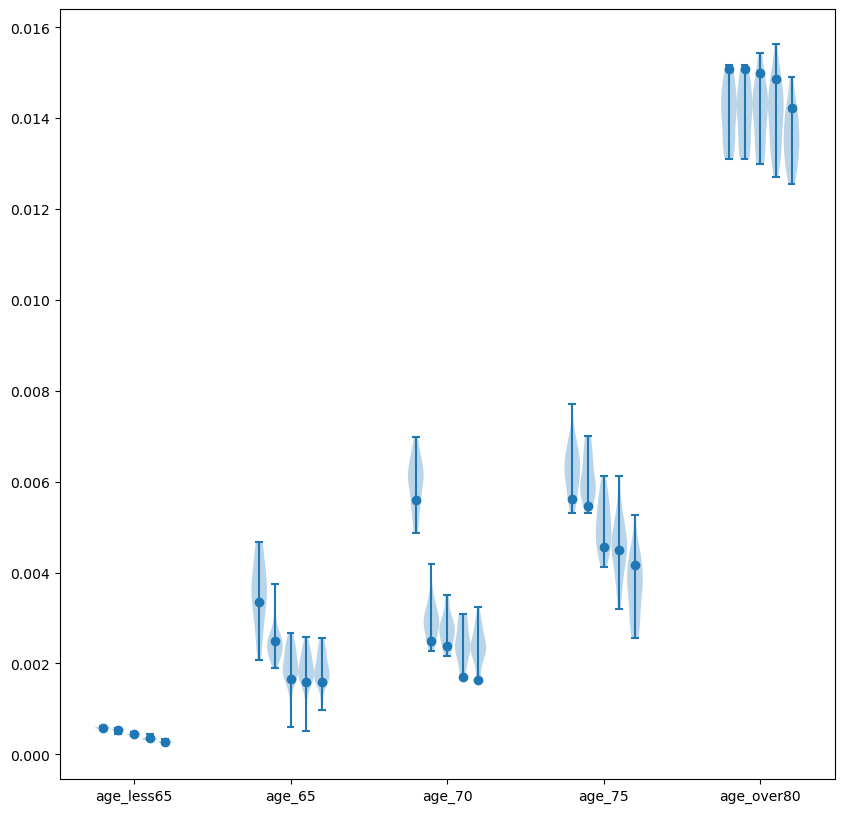

In [504]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.violinplot(df_anneal_results.filter(df_anneal_results['r2_all'] >= 0.595)[coeff_names], positions=positions.flatten(), widths=0.1)

# ax.scatter(positions.flatten(), df_anneal_results_round.filter(df_anneal_results_round['r2_all'] == df_anneal_results_round['r2_all'].max())[coeff_names])
ax.scatter(positions.flatten(), df_anneal_results.filter(df_anneal_results['r2_all'] == df_anneal_results['r2_all'].max())[coeff_names])

ax.set_xticks(np.arange(5))
ax.set_xticklabels(age_numbers)

plt.show()

In [475]:
for best_combo_name in df_anneal_results.sort('r2_all', descending=True)['coeff_combo']:

    df_best = df_anneal_results.filter(df_anneal_results['coeff_combo'] == best_combo_name)
    
    df_best_coeffs = df_best[coeff_names]
    best_coeffs_grid = df_best_coeffs.to_numpy().reshape(5, 5)
    
    df_best_init = df_anneal_init.filter(df_anneal_init['coeff_combo'] == best_combo_name)
    df_best_init_coeffs = df_best_init[coeff_names]
    best_init_coeffs_grid = df_best_init_coeffs.to_numpy().reshape(5, 5)

    print(best_combo_name)
    display(np.round(best_coeffs_grid, 4))
    display(np.round(best_init_coeffs_grid, 4))
    display(np.round(best_coeffs_grid / coeffs_ssnap, 2))
    print('\n'*3)

96


array([[0.0006, 0.0034, 0.0056, 0.0056, 0.0151],
       [0.0005, 0.0025, 0.0025, 0.0055, 0.0151],
       [0.0004, 0.0016, 0.0024, 0.0046, 0.015 ],
       [0.0004, 0.0016, 0.0017, 0.0045, 0.0149],
       [0.0003, 0.0016, 0.0016, 0.0042, 0.0142]])

array([[0.0006, 0.004 , 0.006 , 0.009 , 0.015 ],
       [0.0005, 0.003 , 0.004 , 0.007 , 0.012 ],
       [0.0003, 0.003 , 0.004 , 0.006 , 0.012 ],
       [0.0003, 0.002 , 0.003 , 0.005 , 0.012 ],
       [0.0002, 0.001 , 0.002 , 0.005 , 0.012 ]])

array([[1.44, 1.27, 1.5 , 0.93, 1.31],
       [1.34, 0.94, 0.67, 0.91, 1.31],
       [1.08, 0.62, 0.64, 0.76, 1.3 ],
       [0.9 , 0.61, 0.46, 0.75, 1.29],
       [0.67, 0.6 , 0.44, 0.69, 1.23]])





103


...

array([[1.41, 2.23, 1.63, 1.42, 0.88],
       [1.39, 1.4 , 0.99, 1.39, 0.88],
       [1.1 , 1.07, 0.94, 1.39, 0.87],
       [0.88, 0.95, 0.86, 1.38, 0.85],
       [0.63, 0.95, 0.8 , 1.3 , 0.84]])





41


array([[0.0006, 0.0028, 0.0028, 0.0093, 0.0152],
       [0.0006, 0.0025, 0.0027, 0.0066, 0.0137],
       [0.0004, 0.0021, 0.0026, 0.0057, 0.0137],
       [0.0003, 0.0014, 0.0018, 0.0056, 0.0137],
       [0.0003, 0.0011, 0.0016, 0.0022, 0.0137]])

array([[0.0005, 0.003 , 0.004 , 0.008 , 0.014 ],
       [0.0005, 0.003 , 0.004 , 0.006 , 0.014 ],
       [0.0003, 0.003 , 0.003 , 0.006 , 0.012 ],
       [0.0003, 0.002 , 0.002 , 0.005 , 0.012 ],
       [0.0003, 0.001 , 0.002 , 0.002 , 0.01  ]])

array([[1.41, 1.05, 0.75, 1.55, 1.31],
       [1.41, 0.95, 0.73, 1.1 , 1.18],
       [1.01, 0.79, 0.71, 0.94, 1.18],
       [0.85, 0.51, 0.49, 0.94, 1.18],
       [0.85, 0.4 , 0.43, 0.37, 1.18]])

0.496780756371482
0.584299624978903
0.6438470665168978
0.6147004170926523
0.6277170452752013


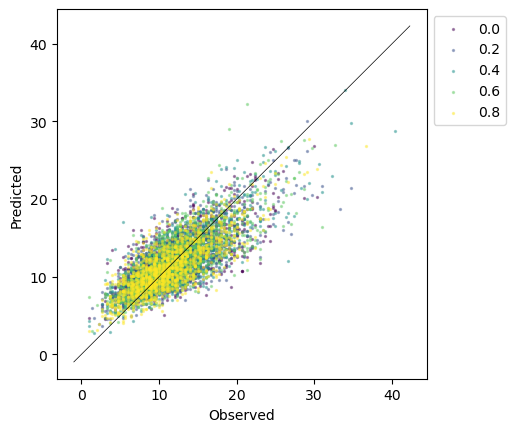

In [495]:
best_combo_name = df_anneal_results.sort('r2_all', descending=True)['coeff_combo'].to_numpy()[0]

df_best = df_anneal_results.filter(df_anneal_results['coeff_combo'] == best_combo_name)

df_best_coeffs = df_best[coeff_names]
best_coeffs_grid = df_best_coeffs.to_numpy().reshape(5, 5)

q_colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(qmin_list)))

fig, ax = plt.subplots()

for i, qmin in enumerate(qmin_list):
    df_here = df_stats.filter(np.round(df_stats['depriv_quantile_min'], 1) == round(qmin, 1))
    coeffs_here = best_coeffs_grid[i, :]
    x_lists = [df_here[a] for a in age_numbers]
    predicted_admissions_here = predict_admissions(x_lists, np.array(coeffs_here))

    ax.scatter(df_here['admissions'], predicted_admissions_here, color=q_colours[i], label=qmin, alpha=0.4, s=2)
    
    r2 = calculate_rsquared(df_here['admissions'], predicted_admissions_here)
    print(r2)

zmax = max([ax.get_xlim()[1], ax.get_ylim()[1]])
zmin = min([ax.get_xlim()[0], ax.get_ylim()[0]])
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')

ax.set_aspect('equal')
ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')

plt.show()

## end

In [281]:
print(stop, here, please)

NameError: name 'stop' is not defined

In [ ]:
len(df_coeffs_init)

In [ ]:
df_best_init = df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == best_combo_name)

df_best_init_coeffs = df_best_init[coeff_names]
best_init_coeffs_grid = df_best_init_coeffs.to_numpy().reshape(5, 5)

best_init_coeffs_grid

In [ ]:
best_coeffs_grid / coeffs_ssnap

In [ ]:
best_init_coeffs_grid / coeffs_ssnap

In [ ]:
df_best_coeffs

In [ ]:
coeffs_ssnap

In [ ]:
q_colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(qmin_list)))

In [ ]:
fig, ax = plt.subplots()

for i, qmin in enumerate(qmin_list):
    ax.scatter(all_admissions[i], results_calculated_admissions[i], s=3, color=q_colours[i], label=round(qmin, 1))

zmax = max([ax.get_xlim()[1], ax.get_ylim()[1]])
zmin = min([ax.get_xlim()[0], ax.get_ylim()[0]])
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')

ax.set_aspect('equal')
ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')

plt.show()

In [ ]:
fig, ax = plt.subplots()

for i, qmin in enumerate(qmin_list):
    df_here = df_stats.filter(np.round(df_stats['depriv_quantile_min'], 1) == round(qmin, 1))
    coeffs_here = coeffs_init_grid[i, :]
    x_lists = [df_here[a] for a in age_numbers]
    predicted_admissions_here = predict_admissions(x_lists, np.array(coeffs_here))

    ax.scatter(df_here['admissions'], predicted_admissions_here, color=q_colours[i], label=qmin, alpha=0.4, s=2)
    
    r2 = calculate_rsquared(df_here['admissions'], predicted_admissions_here)
    print(r2)

zmax = max([ax.get_xlim()[1], ax.get_ylim()[1]])
zmin = min([ax.get_xlim()[0], ax.get_ylim()[0]])
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')

ax.set_aspect('equal')
ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')

plt.show()

In [ ]:
set_option = df_complete_sets.sort('rsquared_combo_set', descending=True)['set_option'][0]

row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)

row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

df_best_set_combo_r2 = pl.concat((row0, row1, row2, row3, row4))

display(df_best_set_combo_r2)

In [ ]:
coeffs_grid

In [ ]:
coeffs_init_grid[0, :]

In [ ]:
coeffs_ssnap

In [ ]:
coeffs_grid = np.array([[0.00049183, 0.00305862, 0.00462389, 0.00945032, 0.01610601],
       [0.00042489, 0.00281324, 0.00372096, 0.00609213, 0.01538321],
       [0.00039448, 0.00218178, 0.00372096, 0.00590925, 0.01290729],
       [0.00039448, 0.00204174, 0.00306873, 0.00558008, 0.0119854 ],
       [0.00030763, 0.00124942, 0.00286133, 0.00557841, 0.01198057]])

In [ ]:
np.round(coeffs_grid / coeffs_ssnap, 2)

In [ ]:
coeffs_grid[1] / coeffs_ssnap